In [1]:
import sys
print(sys.executable)

/home/bowenyuan/miniforge3/envs/embodied/bin/python


In [2]:
from pathlib import Path

print("Current working directory:", Path.cwd())

Current working directory: /home/bowenyuan/Projects/embodied-ai-learning/notebooks


In [3]:
from pathlib import Path
from lerobot.datasets.lerobot_dataset import LeRobotDataset

cwd = Path.cwd()

if cwd.name == "notebooks":
    PROJECT_ROOT = cwd.parent
else:
    PROJECT_ROOT = cwd

DATASET_ROOT = PROJECT_ROOT / "datasets" / "lerobot" / "pickcube"

print("Project root:", PROJECT_ROOT)
print("Dataset root:", DATASET_ROOT)
print("Dataset exists:", DATASET_ROOT.exists())
print("Data exists:", (DATASET_ROOT / "data").exists())
print("Meta exists:", (DATASET_ROOT / "meta").exists())

dataset = LeRobotDataset(
    repo_id="pickcube",
    root=DATASET_ROOT,
)

print("Dataset length:", len(dataset))
print("Episodes:", dataset.num_episodes)
print("FPS:", dataset.fps)

Project root: /home/bowenyuan/Projects/embodied-ai-learning
Dataset root: /home/bowenyuan/Projects/embodied-ai-learning/datasets/lerobot/pickcube
Dataset exists: True
Data exists: True
Meta exists: True
Dataset length: 50
Episodes: 1
FPS: 50


In [4]:
sample = dataset[0]

print("Sample type:", type(sample))
print("\nKeys:")

for key, value in sample.items():
    shape = getattr(value, "shape", None)
    dtype = getattr(value, "dtype", type(value))
    print(f"{key:30s} shape={str(shape):15s} dtype={dtype}")

Sample type: <class 'dict'>

Keys:
observation.state              shape=torch.Size([42]) dtype=torch.float32
action                         shape=torch.Size([8]) dtype=torch.float32
timestamp                      shape=torch.Size([])  dtype=torch.float32
frame_index                    shape=torch.Size([])  dtype=torch.int64
episode_index                  shape=torch.Size([])  dtype=torch.int64
index                          shape=torch.Size([])  dtype=torch.int64
task_index                     shape=torch.Size([])  dtype=torch.int64
task                           shape=None            dtype=<class 'str'>


In [5]:
state = sample["observation.state"]
action = sample["action"]

print("\nState shape:", state.shape)
print("Action shape:", action.shape)

print("\nState:")
print(state)

print("\nAction:")
print(action)


State shape: torch.Size([42])
Action shape: torch.Size([8])

State:
tensor([ 3.5281e-02,  4.0070e-01,  1.9575e-02, -1.9187e+00,  3.7351e-02,
         2.3366e+00,  8.0440e-01,  4.0000e-02,  4.0000e-02,  0.0000e+00,
         0.0000e+00,  0.0000e+00,  0.0000e+00,  0.0000e+00,  0.0000e+00,
         0.0000e+00,  0.0000e+00,  0.0000e+00,  0.0000e+00,  1.2254e-02,
         3.8011e-02,  1.8215e-01, -1.7689e-02,  9.9980e-01,  4.2880e-03,
         7.9842e-03,  2.6816e-02, -1.9813e-03,  2.8893e-01, -7.4868e-04,
         5.3644e-02,  2.0000e-02,  5.6876e-01,  0.0000e+00,  0.0000e+00,
         8.2250e-01, -1.3002e-02,  1.5633e-02, -1.6215e-01,  2.7564e-02,
        -5.5626e-02,  2.6893e-01])

Action:
tensor([ 0.1791,  0.9838,  0.1854, -0.8309, -0.2816, -0.4202, -0.8190,  0.0052])


In [6]:
assert state.shape == (42,)
assert action.shape == (8,)
assert len(dataset) == 50
assert dataset.num_episodes == 1
assert dataset.fps == 50

print("Single-frame inspection: PASS")

Single-frame inspection: PASS


# Create DataLoader

In [5]:
from torch.utils.data import DataLoader

BATCH_SIZE = 8

dataloader = DataLoader(
    dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=0,
)

# Read first Batch

In [6]:
batch = next(iter(dataloader))

print("Batch type:", type(batch))
print("\nBatch fields:")

for key, value in batch.items():
    if hasattr(value, "shape"):
        print(
            f"{key:30s}",
            f"shape={str(value.shape):15s}",
            f"dtype={value.dtype}",
        )
    else:
        print(
            f"{key:30s}",
            f"type={type(value)}",
            f"value={value}",
        )

Batch type: <class 'dict'>

Batch fields:
observation.state              shape=torch.Size([8, 42]) dtype=torch.float32
action                         shape=torch.Size([8, 8]) dtype=torch.float32
timestamp                      shape=torch.Size([8]) dtype=torch.float32
frame_index                    shape=torch.Size([8]) dtype=torch.int64
episode_index                  shape=torch.Size([8]) dtype=torch.int64
index                          shape=torch.Size([8]) dtype=torch.int64
task_index                     shape=torch.Size([8]) dtype=torch.int64
task                           type=<class 'list'> value=['pick up the cube', 'pick up the cube', 'pick up the cube', 'pick up the cube', 'pick up the cube', 'pick up the cube', 'pick up the cube', 'pick up the cube']


In [7]:
states = batch["observation.state"]
actions = batch["action"]

print("States:", states.shape)
print("Actions:", actions.shape)

assert states.shape == (8, 42)
assert actions.shape == (8, 8)

print("Batch inspection: PASS")

States: torch.Size([8, 42])
Actions: torch.Size([8, 8])
Batch inspection: PASS


In [8]:
print("Global indices:", batch["index"])
print("Episode indices:", batch["episode_index"])
print("Frame indices:", batch["frame_index"])
print("Timestamps:", batch["timestamp"])
print("Tasks:", batch["task"])

Global indices: tensor([0, 1, 2, 3, 4, 5, 6, 7])
Episode indices: tensor([0, 0, 0, 0, 0, 0, 0, 0])
Frame indices: tensor([0, 1, 2, 3, 4, 5, 6, 7])
Timestamps: tensor([0.0000, 0.0200, 0.0400, 0.0600, 0.0800, 0.1000, 0.1200, 0.1400])
Tasks: ['pick up the cube', 'pick up the cube', 'pick up the cube', 'pick up the cube', 'pick up the cube', 'pick up the cube', 'pick up the cube', 'pick up the cube']


## Define a Model

In [9]:
import torch
import torch.nn as nn


class MLPPolicy(nn.Module):

    def __init__(
        self,
        #输入状态维度
        state_dim=42,
        #输出动作维度
        action_dim=8,
        #隐藏特征维度
        hidden_dim=128,
    ):
        super().__init__()

        self.network = nn.Sequential(
            nn.Linear(state_dim, hidden_dim),
            nn.ReLU(),

            nn.Linear(hidden_dim, hidden_dim),
            nn.ReLU(),

            nn.Linear(hidden_dim, action_dim),
            nn.Tanh(),
        )

    def forward(self, state):
        return self.network(state)

In [10]:
policy = MLPPolicy()

print(policy)

MLPPolicy(
  (network): Sequential(
    (0): Linear(in_features=42, out_features=128, bias=True)
    (1): ReLU()
    (2): Linear(in_features=128, out_features=128, bias=True)
    (3): ReLU()
    (4): Linear(in_features=128, out_features=8, bias=True)
    (5): Tanh()
  )
)


In [11]:
states = batch["observation.state"]
target_actions = batch["action"]

print("States shape:", states.shape)
print("Target actions shape:", target_actions.shape)

States shape: torch.Size([8, 42])
Target actions shape: torch.Size([8, 8])


In [12]:
predicted_actions = policy(states)

In [13]:
print("Input state 0:")
print(states[0])

print("\nPredicted action 0:")
print(predicted_actions[0])

print("\nTarget action 0:")
print(target_actions[0])

Input state 0:
tensor([ 3.5281e-02,  4.0070e-01,  1.9575e-02, -1.9187e+00,  3.7351e-02,
         2.3366e+00,  8.0440e-01,  4.0000e-02,  4.0000e-02,  0.0000e+00,
         0.0000e+00,  0.0000e+00,  0.0000e+00,  0.0000e+00,  0.0000e+00,
         0.0000e+00,  0.0000e+00,  0.0000e+00,  0.0000e+00,  1.2254e-02,
         3.8011e-02,  1.8215e-01, -1.7689e-02,  9.9980e-01,  4.2880e-03,
         7.9842e-03,  2.6816e-02, -1.9813e-03,  2.8893e-01, -7.4868e-04,
         5.3644e-02,  2.0000e-02,  5.6876e-01,  0.0000e+00,  0.0000e+00,
         8.2250e-01, -1.3002e-02,  1.5633e-02, -1.6215e-01,  2.7564e-02,
        -5.5626e-02,  2.6893e-01])

Predicted action 0:
tensor([-0.0160,  0.0257, -0.0166,  0.0328,  0.1051, -0.0548,  0.0241, -0.0356],
       grad_fn=<SelectBackward0>)

Target action 0:
tensor([ 0.1791,  0.9838,  0.1854, -0.8309, -0.2816, -0.4202, -0.8190,  0.0052])


In [14]:
assert predicted_actions.shape == target_actions.shape

assert torch.all(predicted_actions >= -1.0)
assert torch.all(predicted_actions <= 1.0)

print("Policy forward pass: PASS")

Policy forward pass: PASS


In [15]:
print("Prediction for sample 0:")
print(predicted_actions[0])

print("\nPrediction for sample 1:")
print(predicted_actions[1])

print("\nDifference:")
print(predicted_actions[1] - predicted_actions[0])

Prediction for sample 0:
tensor([-0.0160,  0.0257, -0.0166,  0.0328,  0.1051, -0.0548,  0.0241, -0.0356],
       grad_fn=<SelectBackward0>)

Prediction for sample 1:
tensor([-0.0121,  0.0007, -0.0309,  0.0402,  0.0908, -0.0546,  0.0276, -0.0446],
       grad_fn=<SelectBackward0>)

Difference:
tensor([ 0.0039, -0.0250, -0.0143,  0.0074, -0.0143,  0.0002,  0.0035, -0.0090],
       grad_fn=<SubBackward0>)


# 4.1 Define MSE Loss

In [16]:
loss_fn = nn.MSELoss()

## 4.2 Loss calculation

In [17]:
loss = loss_fn(
    predicted_actions,
    target_actions,
)

print("Loss tensor:", loss)
print("Loss value:", loss.item())

Loss tensor: tensor(0.3494, grad_fn=<MseLossBackward0>)
Loss value: 0.3494274914264679


In [18]:
print("Loss shape:", loss.shape)
print("Loss requires grad:", loss.requires_grad)
print("Loss grad_fn:", loss.grad_fn)

Loss shape: torch.Size([])
Loss requires grad: True
Loss grad_fn: <MseLossBackward0 object at 0x760b24ec1b40>


In [19]:
prediction_0 = predicted_actions[0]
target_0 = target_actions[0]

difference_0 = prediction_0 - target_0
squared_error_0 = difference_0 ** 2
sample_mse_0 = squared_error_0.mean()

print("Prediction 0:")
print(prediction_0)

print("\nTarget 0:")
print(target_0)

print("\nDifference:")
print(difference_0)

print("\nSquared error:")
print(squared_error_0)

print("\nSample 0 MSE:")
print(sample_mse_0.item())

Prediction 0:
tensor([-0.0160,  0.0257, -0.0166,  0.0328,  0.1051, -0.0548,  0.0241, -0.0356],
       grad_fn=<SelectBackward0>)

Target 0:
tensor([ 0.1791,  0.9838,  0.1854, -0.8309, -0.2816, -0.4202, -0.8190,  0.0052])

Difference:
tensor([-0.1952, -0.9581, -0.2020,  0.8637,  0.3868,  0.3654,  0.8432, -0.0408],
       grad_fn=<SubBackward0>)

Squared error:
tensor([0.0381, 0.9179, 0.0408, 0.7460, 0.1496, 0.1335, 0.7109, 0.0017],
       grad_fn=<PowBackward0>)

Sample 0 MSE:
0.34230509400367737


In [20]:
per_element_squared_error = (
    predicted_actions - target_actions
) ** 2

per_sample_mse = per_element_squared_error.mean(dim=1)

print("Per-sample MSE:")
print(per_sample_mse)

print("Shape:", per_sample_mse.shape)

Per-sample MSE:
tensor([0.3423, 0.3456, 0.3083, 0.3136, 0.4324, 0.5616, 0.2848, 0.2067],
       grad_fn=<MeanBackward1>)
Shape: torch.Size([8])


In [21]:
manual_batch_loss = per_sample_mse.mean()

print("PyTorch loss:", loss.item())
print("Manual loss:", manual_batch_loss.item())

assert torch.allclose(
    loss,
    manual_batch_loss,
)

print("MSE verification: PASS")

PyTorch loss: 0.3494274914264679
Manual loss: 0.3494274914264679
MSE verification: PASS


In [22]:
per_action_dim_mse = (
    (predicted_actions - target_actions) ** 2
).mean(dim=0)

print("Per-action-dimension MSE:")

for i, value in enumerate(per_action_dim_mse):
    name = f"joint_{i + 1}" if i < 7 else "gripper"
    print(f"{name:10s}: {value.item():.6f}")

Per-action-dimension MSE:
joint_1   : 0.540308
joint_2   : 0.476761
joint_3   : 0.300926
joint_4   : 0.409451
joint_5   : 0.125006
joint_6   : 0.296024
joint_7   : 0.303524
gripper   : 0.343421


In [23]:
print("Batch MSE:", loss.item())
print("Per-sample MSE:", per_sample_mse)
print("Per-action-dimension MSE:", per_action_dim_mse)
print("MSE verification: PASS")

Batch MSE: 0.3494274914264679
Per-sample MSE: tensor([0.3423, 0.3456, 0.3083, 0.3136, 0.4324, 0.5616, 0.2848, 0.2067],
       grad_fn=<MeanBackward1>)
Per-action-dimension MSE: tensor([0.5403, 0.4768, 0.3009, 0.4095, 0.1250, 0.2960, 0.3035, 0.3434],
       grad_fn=<MeanBackward1>)
MSE verification: PASS


# 2.8.5.1 Create a Optimizer

In [24]:
optimizer = torch.optim.Adam(
    policy.parameters(),
    lr=1e-3,
)

In [25]:
first_layer = policy.network[0]

weight_before = first_layer.weight.detach().clone()

print("First layer weight shape:")
print(weight_before.shape)

First layer weight shape:
torch.Size([128, 42])


In [26]:
optimizer.zero_grad()
predicted_actions = policy(states)
loss_before = loss_fn(
    predicted_actions,
    target_actions,
)

print("Loss before update:", loss_before.item())

Loss before update: 0.3494274914264679


In [27]:
loss_before.backward()

print("Gradient exists:")
print(first_layer.weight.grad is not None)

print("Gradient shape:")
print(first_layer.weight.grad.shape)

print("Gradient norm:")
print(first_layer.weight.grad.norm().item())

Gradient exists:
True
Gradient shape:
torch.Size([128, 42])
Gradient norm:
0.10567158460617065


In [28]:
import torch

optimizer = torch.optim.Adam(
    policy.parameters(),
    lr=1e-3,
)

first_layer = policy.network[0]
weight_before = first_layer.weight.detach().clone()

optimizer.zero_grad()

predicted_actions = policy(states)

loss_before = loss_fn(
    predicted_actions,
    target_actions,
)

loss_before.backward()

print("Gradient exists:",
      first_layer.weight.grad is not None)

print("Gradient shape:",
      first_layer.weight.grad.shape)

print("Gradient norm:",
      first_layer.weight.grad.norm().item())

optimizer.step()

weight_after = first_layer.weight.detach().clone()

with torch.no_grad():
    predictions_after = policy(states)

    loss_after = loss_fn(
        predictions_after,
        target_actions,
    )

print("\nLoss before:", loss_before.item())
print("Loss after:", loss_after.item())

print("Mean absolute weight change:",
      (weight_after - weight_before).abs().mean().item())

assert not torch.equal(weight_before, weight_after)

print("Backward and optimizer step: PASS")

Gradient exists: True
Gradient shape: torch.Size([128, 42])
Gradient norm: 0.10567158460617065

Loss before: 0.3494274914264679
Loss after: 0.3357880413532257
Mean absolute weight change: 0.0005913344211876392
Backward and optimizer step: PASS


# 扩展为整个训练集

In [29]:
from torch.utils.data import DataLoader

train_loader = DataLoader(
    dataset,
    batch_size=8,
    shuffle=True,
)

print("Number of batches per epoch:", len(train_loader))

Number of batches per epoch: 7


In [30]:
import torch
import torch.nn as nn

torch.manual_seed(42)

policy = MLPPolicy(
    state_dim=42,
    action_dim=8,
    hidden_dim=128,
)

loss_fn = nn.MSELoss()

optimizer = torch.optim.Adam(
    policy.parameters(),
    lr=1e-3,
)

num_epochs = 100
loss_history = []

for epoch in range(num_epochs):

    policy.train()

    total_loss = 0.0
    total_samples = 0

    for batch in train_loader:

        states = batch["observation.state"]
        target_actions = batch["action"]

        # 1. 清空上一批次的梯度
        optimizer.zero_grad()

        # 2. 正向传播
        predicted_actions = policy(states)

        # 3. 计算 Loss
        loss = loss_fn(
            predicted_actions,
            target_actions,
        )

        # 4. 反向传播，计算梯度
        loss.backward()

        # 5. 更新模型参数
        optimizer.step()

        batch_size = states.shape[0]

        total_loss += loss.item() * batch_size
        total_samples += batch_size

    epoch_loss = total_loss / total_samples
    loss_history.append(epoch_loss)

    if epoch == 0 or (epoch + 1) % 10 == 0:
        print(
            f"Epoch {epoch + 1:3d}/{num_epochs}, "
            f"Loss: {epoch_loss:.6f}"
        )

print("Training loop: PASS")

Epoch   1/100, Loss: 0.346221
Epoch  10/100, Loss: 0.311921
Epoch  20/100, Loss: 0.283204
Epoch  30/100, Loss: 0.257555
Epoch  40/100, Loss: 0.235111
Epoch  50/100, Loss: 0.211261
Epoch  60/100, Loss: 0.191730
Epoch  70/100, Loss: 0.169733
Epoch  80/100, Loss: 0.147206
Epoch  90/100, Loss: 0.124716
Epoch 100/100, Loss: 0.105965
Training loop: PASS


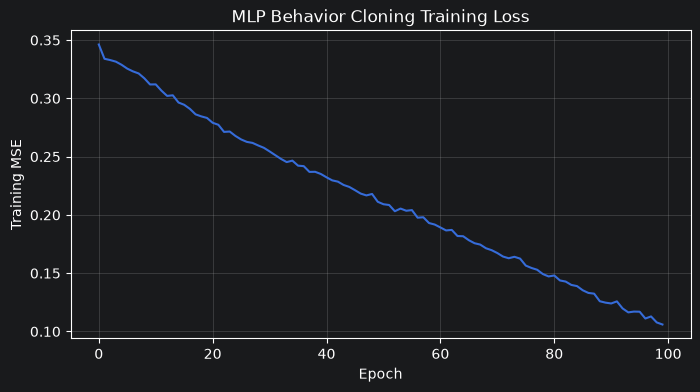

In [31]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 4))

plt.plot(loss_history)

plt.xlabel("Epoch")
plt.ylabel("Training MSE")
plt.title("MLP Behavior Cloning Training Loss")
plt.grid(alpha=0.3)

plt.show()